In [1]:
import warnings
from io import StringIO
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
import pandas as pd
import requests
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import ConstantKernel as C

warnings.filterwarnings("ignore", category=ConvergenceWarning)

rc("font", weight="bold")
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams.update({"font.size": 12, "axes.labelsize": 14})

project_root = Path.cwd().parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import python_zapocet_funkce

In [2]:
shotlist = [
    51820, 51821, 51822, 51823, 51824, 51825, 51826, 51827, 51828, 51829, 51830, 51831, 51832, 51833, 51834
]
rs = [98, 94, 90, 86, 82, 78, 74, 70, 66, 62, 58, 54, 50, 46, 42]


# Define constants for Te analysis
alpha = 2.0
BPP_alpha = 0.9
Te_shift = 0.5

# voltage divider on circuit
R_LP = 100
R_BPP = 100

# time binning
step_phi = 2

C_min_phi=1e-2
C_max_phi=1e3
RBF_min_phi=2e1
RBF_max_phi=2e2

noise_min = 1e-4
noise_max = 1e-1

# number of realizations
n_samples = 20


color_map = LinearSegmentedColormap.from_list("custom_blue_red", ["blue", "red"])

c:\Users\kryst\anaconda3\envs\camera\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kryst\anaconda3\envs\camera\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kryst\anaconda3\envs\camera\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kryst\anaconda3\envs\camera\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\kryst\AppData\Local\Temp\ipykernel_14208\808902418.py:40: FutureWarning: In a future version of xarray the default value for coords will change from coords='different'

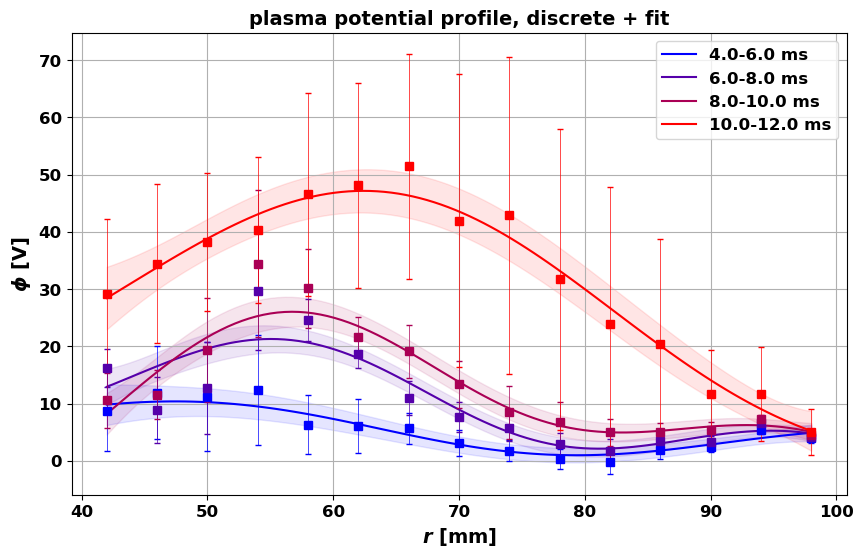

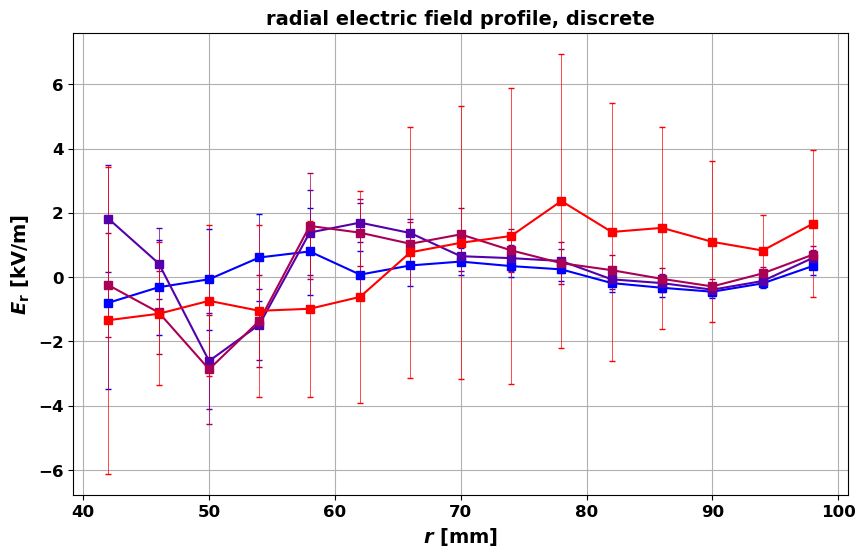

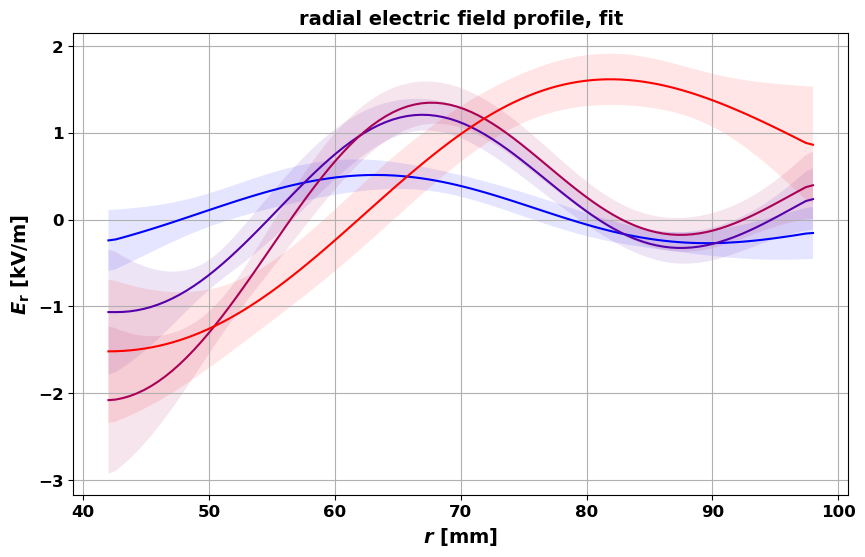

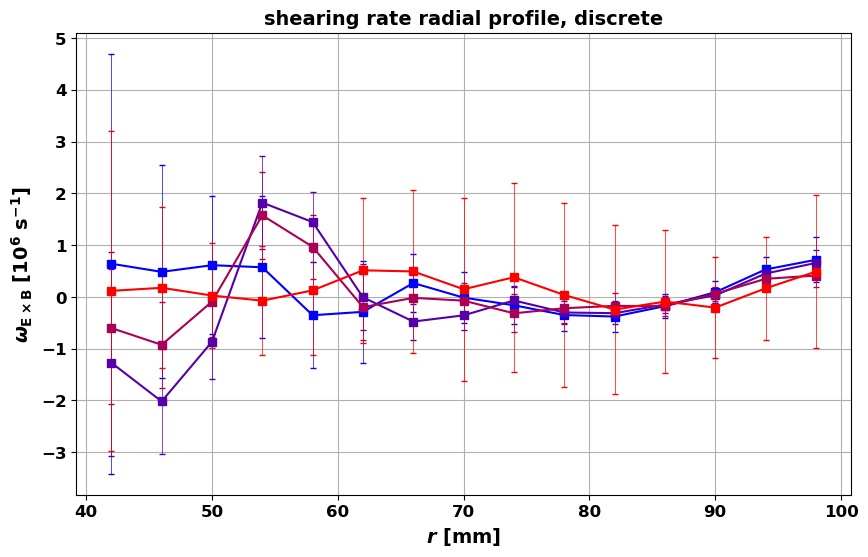

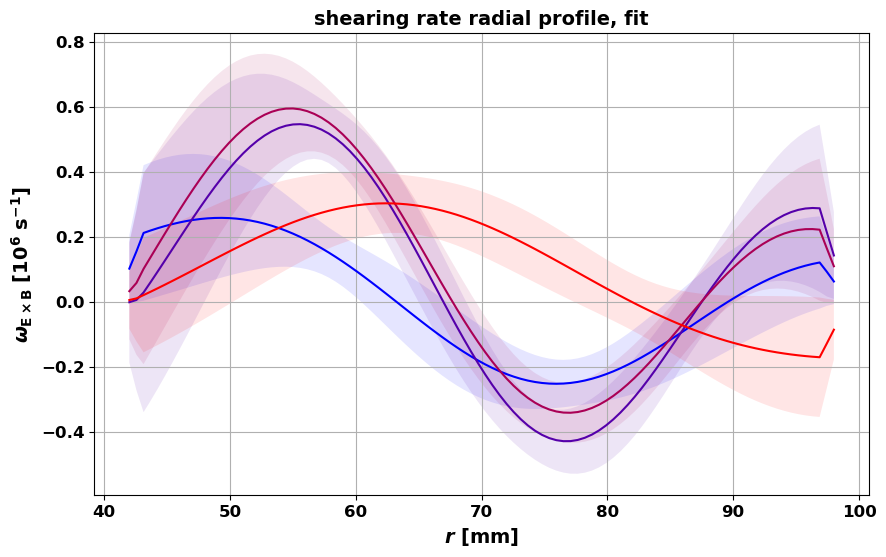

In [3]:
t1, t2 = python_zapocet_funkce.get_plasma_times(shotlist)

ds_mean_phi, ds_std_phi, t_bins_phi = python_zapocet_funkce.process_dataset(
    shotlist, rs, alpha, Te_shift, BPP_alpha, R_BPP, R_LP, t1, t2, step_phi
 )
to_cycle_phi = ds_mean_phi.t_bins.size

Ers_mean_fit, Ers_ci_lower_fit, Ers_ci_upper_fit, v_pol_mean_fit, v_pol_ci_lower_fit, v_pol_ci_upper_fit, omega_s_mean_fit, omega_s_ci_lower_fit, omega_s_ci_upper_fit = python_zapocet_funkce.compute_phi_Er_vpol_omega_s_fit(
    ds_mean_phi, ds_std_phi, to_cycle_phi, C_min_phi, C_max_phi, RBF_min_phi, RBF_max_phi, noise_min, noise_max, n_samples
 )
Ers_mean_discrete, Ers_std_discrete, v_pol_mean_discrete, v_pol_std_discrete, omega_s_mean_discrete, omega_s_std_discrete = python_zapocet_funkce.compute_phi_Er_vpol_omega_s_discrete(
    ds_mean_phi, ds_std_phi, to_cycle_phi
 )

fig, ax1 = plt.subplots(figsize=(10, 6))
fig, ax2 = plt.subplots(figsize=(10, 6))
fig, ax3 = plt.subplots(figsize=(10, 6))
fig, ax4 = plt.subplots(figsize=(10, 6))
fig, ax5 = plt.subplots(figsize=(10, 6))

python_zapocet_funkce.plot_phi_discrete_and_fit(
    ax1,
    ds_mean_phi,
    ds_std_phi,
    t_bins_phi,
    step_phi,
    t1,
    to_cycle_phi,
    C_min_phi,
    C_max_phi,
    RBF_min_phi,
    RBF_max_phi,
    noise_min,
    noise_max,
    n_samples,
    color_map,
 )
python_zapocet_funkce.plot_er_discrete(
    ax2,
    xr.concat(Ers_mean_discrete, dim="t"),
    xr.concat(Ers_std_discrete, dim="t"),
    t_bins_phi,
    step_phi,
    t1,
    to_cycle_phi,
 )
python_zapocet_funkce.plot_er_fit(
    ax3,
    xr.concat(Ers_mean_fit, dim="t"),
    xr.concat(Ers_ci_lower_fit, dim="t"),
    xr.concat(Ers_ci_upper_fit, dim="t"),
    t_bins_phi,
    step_phi,
    t1,
    to_cycle_phi,
 )
python_zapocet_funkce.plot_omega_shearing_discrete(
    ax4,
    xr.concat(omega_s_mean_discrete, dim="t"),
    xr.concat(omega_s_std_discrete, dim="t"),
    t_bins_phi,
    step_phi,
    t1,
    to_cycle_phi,
 )
python_zapocet_funkce.plot_omega_shearing_fit(
    ax5,
    xr.concat(omega_s_mean_fit, dim="t"),
    xr.concat(omega_s_ci_lower_fit, dim="t"),
    xr.concat(omega_s_ci_upper_fit, dim="t"),
    t_bins_phi,
    step_phi,
    t1,
    to_cycle_phi,
 )
plt.show()